
Fit summary:
20251206: offset (mG) = 0.000, resid (mG) = 0.021
[ 3.11319835e-04  1.72029715e-05  8.69522225e-05  3.53887666e-05
  3.54126905e-05  1.01175901e-05  1.20015244e-05 -2.40872584e-05
  1.84342278e-05  5.77106875e-06]
[-0.74266496  0.20733481 -1.94638576 -0.31734924 -0.79121888  0.97772887
 -0.83711628 -0.45627384 -0.21186873 -4.48722767]
20260212: offset (mG) = 0.000, resid (mG) = 0.027
[ 3.07720444e-04  5.53939863e-06  9.66252665e-05  9.24572265e-06
  4.29643176e-05 -1.15080494e-05 -7.80775361e-06  2.56690588e-06
 -1.95084290e-05 -4.49869412e-06]
[-7.07861963  0.13028028 -2.12865138 -0.44897263 -0.5416073  20.15703439
 -0.38514017  0.12499421  4.43925337  0.56771661]
20260403: offset (mG) = 0.000, resid (mG) = 0.028
[ 3.22508460e-04 -6.46331158e-06 -1.05769738e-04  1.94042497e-05
  2.55136001e-05  2.24118440e-05 -3.39055635e-05  4.52798729e-06
  1.59882165e-05  1.07715802e-05]
[-0.75763246 -1.24984313 -5.37791069  0.41436355 -0.55324416 -2.20151253
  0.68640079 -1.68311775 

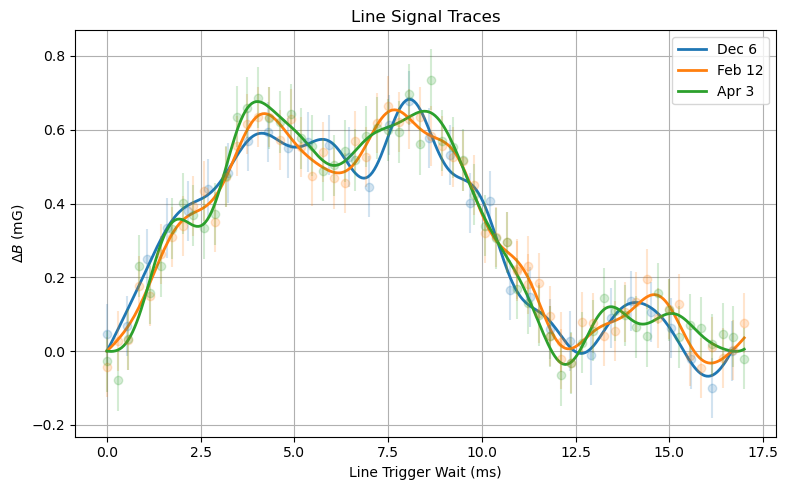

In [ ]:
import os
from datetime import datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# from class_barium import Barium
# from plot_utils import nice_fonts

# mpl.rcParams.update(nice_fonts)
# np.set_printoptions(suppress=True)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


def _human_label(date_str):
    """Return human-readable label like 'Feb 12' for an input containing YYYYMMDD.

    If an 8-digit YYYYMMDD substring is found it is parsed; otherwise the original
    string is returned.
    """
    import re
    m = re.search(r'(\d{8})', date_str)
    if not m:
        return date_str
    try:
        d = datetime.strptime(m.group(1), '%Y%m%d')
        return f"{d.strftime('%b')} {d.day}"
    except Exception:
        return date_str


def _read_files_for_date(folder_path_root,
                         filenames,
                         Ramsey_wait_time,
                         insensB_sens,
                         sensB_sens,
                         num_markers=20,
                         max_iter=200):
    """Read files (list of filenames) and return LT_waits, mag_fields, mag_fields_error, marker_count

    Uses the same parsing logic as ms0_line_signal in line_signal_probe.py: files are
    grouped into runs by detecting LT_wait == 0 which increments the marker.
    """
    LT_waits = np.full((num_markers, max_iter), np.nan)
    mag_fields = np.full((num_markers, max_iter), np.nan)
    ref_mag_fields = np.full((num_markers, max_iter), np.nan)
    mag_fields_error = np.full((num_markers, max_iter), np.nan)

    Ramsey_fit_error = np.sqrt(
        (2 * 0.5 * 0.5) / 250) / (2 * np.pi * Ramsey_wait_time
                                  )  # in kHz, keep default 250 shots in error

    itera = 0
    marker = -1
    for idx, filename in enumerate(filenames):
        file_path = os.path.join(folder_path_root, filename)
        try:
            with open(file_path, 'r') as fh:
                lines = fh.readlines()
        except Exception:
            continue
        if not lines:
            continue
        try:
            LT_wait = float(lines[0].strip())
        except Exception:
            continue
        # If this is the first valid file, start marker 0. Otherwise,
        # treat LT_wait == 0 as the start of a new marker/run only if we
        # already have entries (itera != 0) in the current marker.
        if marker == -1:
            marker = 0
            itera = 0
        elif LT_wait == 0 and itera != 0:
            marker += 1
            itera = 0
        if marker < 0 or marker >= num_markers:
            # skip unexpected
            itera += 1
            continue
        LT_waits[marker, itera] = LT_wait

        if len(lines) > 1:
            try:
                tuple_line = eval(lines[1].strip())
            except Exception:
                tuple_line = None
            # some files include reference tuple on line 3 (index 3)
            ref_tuple_line = None
            if len(lines) > 3:
                try:
                    ref_tuple_line = eval(lines[3].strip())
                except Exception:
                    ref_tuple_line = None

            if tuple_line is not None:
                # in ms0-based files the code uses ref_tuple_line to compute
                # ref and current delta freqs. If ref_tuple_line missing, fall
                # back to using tuple_line as both current and ref (will give 0)
                ins = tuple_line[0]
                sen = tuple_line[1]

                if ref_tuple_line is not None:
                    ref_delta_freq = ref_tuple_line[1] - ref_tuple_line[0]
                else:
                    ref_delta_freq = sen - ins

                current_delta_freq = sen - ins

                # ref_new_mag_value and new_mag_value as in original script
                # the first_ref_delta_freq handling happens on LT_wait==0 across
                # an entire set; here we set first_ref_delta_freq when marker's
                # first measurement (itera==0 and LT_wait==0)
                if itera == 0 and LT_wait == 0:
                    first_ref_delta_freq = ref_delta_freq
                else:
                    # if first_ref not set for this marker, try to keep a default
                    try:
                        _ = first_ref_delta_freq
                    except NameError:
                        first_ref_delta_freq = ref_delta_freq

                ref_new_mag_value = (ref_delta_freq - first_ref_delta_freq) / (
                    sensB_sens - insensB_sens)
                new_mag_value = (current_delta_freq -
                                 ref_delta_freq) / (sensB_sens - insensB_sens)

                mag_fields[marker, itera] = new_mag_value
                ref_mag_fields[marker, itera] = ref_new_mag_value
                mag_fields_error[marker, itera] = (2 * Ramsey_fit_error) / (
                    sensB_sens - insensB_sens)
        itera += 1
    # count markers
    marker_count = -1
    for m in range(num_markers):
        if not np.all(np.isnan(LT_waits[m, :])):
            marker_count = m
    return LT_waits, mag_fields, mag_fields_error, marker_count


def ms0_line_signal_by_dates(
    dates,
    Ramsey_wait_time=50,
    sens_list_f1=None,
    folder_path_root=('Z:\\Lab Data\\Line_signal_characterisation\\')):
    """Process ms0-based line-signal files for the provided list of date strings.

    dates : list of str
        Substrings to match in filenames. Examples: ['20260220', '20260221']
        The function will include any file whose name contains the RamseyWait
        string (e.g. 'RamseyWait50us') and also contains the date substring.

    Produces a single plot overlaying measured magnetic-field points per date
    and the fitted 10-frequency curve for each date. Returns a dict of fit
    parameters per date: {date: (amps, phases, offset, resid_mG)}.
    """

    # prepare sensitivities
   
    insensB_sens = 40e-6 # MHz/G, 
    sensB_sens = 3.42017 # MHz/G,

    file_string = 'RamseyWait' + str(Ramsey_wait_time) + 'us'

    fit_results = {}

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    for idx_date, date_str in enumerate(dates):
        # collect matching files
        try:
            all_files = os.listdir(folder_path_root)
        except Exception as e:
            print(f"Could not list directory {folder_path_root}: {e}")
            return fit_results

        matching_files = [
            f for f in all_files if file_string in f and date_str in f
        ]
        if not matching_files:
            print(
                f"No files found for date {date_str} and Ramsey wait {Ramsey_wait_time}us"
            )
            continue
        # sort by modification time increasing
        matching_files = sorted(
            matching_files,
            key=lambda f: os.path.getmtime(os.path.join(folder_path_root, f)))

        LT_waits, mag_fields, mag_fields_error, marker = _read_files_for_date(
            folder_path_root, matching_files, Ramsey_wait_time, insensB_sens,
            sens_list_f1[idx_date])

        # flatten and remove NaNs
        LT_waits_1d = LT_waits[~np.isnan(LT_waits)]
        mag_fields_1d = mag_fields[~np.isnan(mag_fields)]
        if LT_waits_1d.size == 0:
            print(f"No usable data for {date_str}")
            continue

        # Fit 10-frequency model
        freqs = np.arange(60, 601, 60)

        def sine_fit_function(x, *params):
            a = params[:10]
            phi = params[10:20]
            b = params[20]
            result = np.zeros_like(x, dtype=float)
            for i, f in enumerate(freqs):
                result += a[i] * np.sin(2 * np.pi * f * x * 1e-6 + phi[i])
            return result + b

        amp_estimate = (np.nanmax(mag_fields_1d) -
                        np.nanmin(mag_fields_1d)) / (2 * 10)
        initial_guess = np.concatenate([
            np.full(10, amp_estimate),
            np.zeros(10), [np.nanmean(mag_fields_1d)]
        ])

        try:
            popt, _ = curve_fit(sine_fit_function,
                                LT_waits_1d,
                                mag_fields_1d,
                                p0=initial_guess,
                                maxfev=20000)
        except Exception as e:
            print(f"Fit failed for {date_str}: {e}")
            continue

        a = popt[:10]
        phi = popt[10:20]
        b = popt[20]

        # compute fitted curve for plotting
        LT_waits_fit = np.linspace(np.nanmin(LT_waits), np.nanmax(LT_waits),
                                   300)
        mag_fields_fit = sine_fit_function(LT_waits_fit, *popt)
        mag_fields_0 = sine_fit_function(np.array([0]), *popt)
        # make all offsets zero by subtracting fitted offset b from data and fits
        b_orig = mag_fields_0#b
        # subtract from mag_fields (per-marker array)
        mag_fields = mag_fields - b_orig
        # subtract from fitted curve
        mag_fields_fit = mag_fields_fit - b_orig
        # set reported offset to zero
        b = 0.0

        # collect all points across markers for this date into single arrays
        all_LT = np.array([])
        all_mag = np.array([])
        all_err = np.array([])
        for m in range(marker + 1):
            mask = ~np.isnan(LT_waits[m, :])
            if not np.any(mask):
                continue
            all_LT = np.concatenate([all_LT, LT_waits[m, mask]])
            all_mag = np.concatenate([all_mag, mag_fields[m, mask]])
            all_err = np.concatenate(
                [all_err, np.abs(mag_fields_error[m, mask])])

        color = colors[idx_date % len(colors)]
        marker_style = 'o'
        linestyle = ['-', '--', '-.', ':'][idx_date % 4]

        if all_LT.size > 0:
            # sort by LT for nicer plotting
            sorter = np.argsort(all_LT)
            all_LT = all_LT[sorter]
            all_mag = all_mag[sorter]
            all_err = all_err[sorter]

            # plot combined data points for the date (no legend entry)
            # make measured points faded so fit lines stand out
            ax.errorbar(1e-3 * all_LT,
                        1e3 * all_mag,
                        yerr=1e3 * all_err,
                        fmt=marker_style,
                        color=color,
                        alpha=0.2,
                        label=None)

        # plot fit line as solid colour (same colour as points), full alpha
        human_label = _human_label(date_str)
        ax.plot(1e-3 * LT_waits_fit,
                1e3 * mag_fields_fit,
                color=color,
                linestyle='-',
                linewidth=2.0,
                alpha=1.0,
                label=f"{human_label}")

        # save fit results
        mag_fields_fit_diff = mag_fields - sine_fit_function(LT_waits, *popt)
        resid_mG = 1e3 * np.nanmean(np.abs(mag_fields_fit_diff))
        fit_results[date_str] = (a, phi, b, resid_mG)

        # optional: write per-date fit file
        out_dir = 'line_signal_measurements'
        os.makedirs(out_dir, exist_ok=True)
        ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        fname = os.path.join(
            out_dir, f'ms0_fit_{date_str}_{Ramsey_wait_time}us_{ts}.txt')
        # with open(fname, 'w') as fh:
        #     fh.write(f'# ms0_line_signal fit results for date {date_str}\n')
        #     fh.write(f'# timestamp: {ts}\n')
        #     fh.write(f'# Ramsey_wait_time (us): {Ramsey_wait_time}\n')
        #     fh.write('#freq(Hz)\tamp(mG)\tphase(rad)\n')
        #     for ff, aa, ph in zip(freqs, 1e3 * a, np.mod(phi, 2 * np.pi)):
        #         fh.write(f'{int(ff)}\t{aa:.6e}\t{ph:.6e}\n')
        #     fh.write(f'offset_mG\t{1e3*b:.6e}\n')
        #     fh.write(f'resid_fit_vs_meas_mG\t{resid_mG:.6e}\n')
        # print(f'Fit saved to: {fname}')

    ax.set_title('Line Signal Traces')
    ax.set_xlabel('Line Trigger Wait (ms)')
    ax.set_ylabel(r'$\Delta B$ (mG)')
    ax.grid()
    ax.legend()
    plt.tight_layout()

    # # --- Plot amplitudes per frequency vs. date ---
    # if fit_results:
    #     freqs = np.arange(60, 601, 60)
    #     date_dts = []
    #     date_amps = []
    #     import re
    #     for date_str, (a, phi, b, resid) in fit_results.items():
    #         m = re.search(r'(\d{8})', date_str)
    #         if not m:
    #             continue
    #         try:
    #             dt = datetime.strptime(m.group(1), '%Y%m%d')
    #         except Exception:
    #             continue
    #         date_dts.append(dt)
    #         date_amps.append(1e3 * np.array(np.absolute(a)))  # convert to mG

    #     if len(date_dts) > 0:
    #         # sort by date
    #         order = sorted(range(len(date_dts)), key=lambda k: date_dts[k])
    #         date_dts = [date_dts[i] for i in order]
    #         amps_matrix = np.vstack([date_amps[i]
    #                                  for i in order])  # shape (n_dates, 10)
    #         amps_matrix = amps_matrix.T  # shape (10, n_dates)

    #         fig2, ax2 = plt.subplots(figsize=(8, 5))
    #         cmap = plt.get_cmap('tab10')
    #         for i, f in enumerate(freqs):
    #             col = cmap(i % 10)
    #             ax2.plot(date_dts,
    #                      amps_matrix[i],
    #                      marker='o',
    #                      linestyle='-',
    #                      color=col,
    #                      label=f'{int(f)} Hz')

    #         ax2.set_title('Fitted amplitudes per frequency')
    #         ax2.set_ylabel('Amplitude (mG)')
    #         ax2.set_xlabel('Date')
    #         ax2.grid()
    #         ax2.legend(ncol=2, fontsize='small')
    #         fig2.autofmt_xdate()
    #         plt.tight_layout()

    return fit_results


if __name__ == '__main__':
    # Example usage: change dates to your desired list
    dates = [
        '20251206',
        '20260113',
        '20260212',
        '20260220',
        '20260403',
    ]

    sens_list_f1 = [3.49923, 3.49923, 3.42017, 3.42017, 3.42017]

    fits = ms0_line_signal_by_dates(dates, Ramsey_wait_time=50, sens_list_f1 = sens_list_f1)
    print('\nFit summary:')
    for d, res in fits.items():
        a, phi, b, resid = res
        print(f"{d}: offset (mG) = {1e3*b:.3f}, resid (mG) = {resid:.3f}")
        print(a)
        print(phi)
    plt.show()



Permanent Magnets Fit Parameter Uncertainties:
A_60 ± ΔA_60: 0.000309 ± 0.000013
phi_60 ± Δphi_60: -0.751941 ± 0.036423
A_180 ± ΔA_180: 0.000082 ± 0.000011
phi_180 ± Δphi_180: -1.952209 ± 0.144911
Offset ± ΔOffset: 0.000321 ± 0.000008

New Permanent Magnets Fit Parameter Uncertainties:
A_60 ± ΔA_60: 0.000313 ± 0.000007
phi_60 ± Δphi_60: -0.839251 ± 0.021408
A_180 ± ΔA_180: 0.000119 ± 0.000007
phi_180 ± Δphi_180: -2.118653 ± 0.057180
Offset ± ΔOffset: -0.001451 ± 0.000005


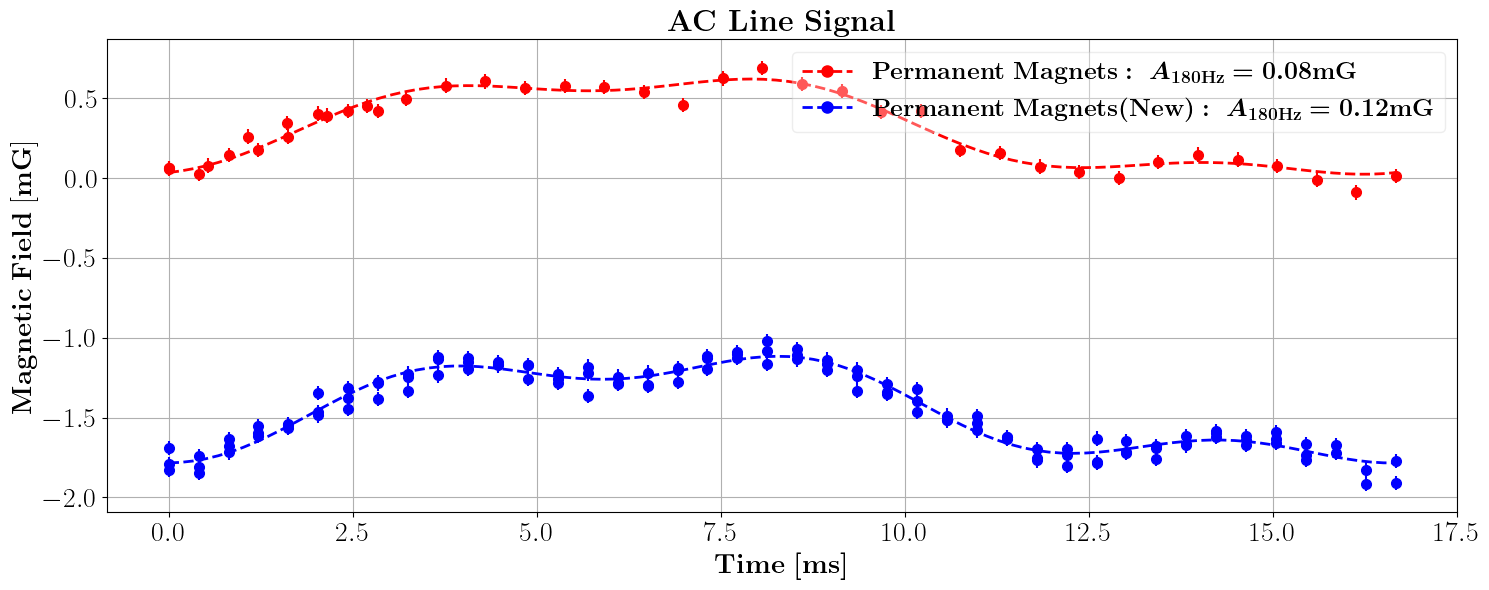

In [18]:
import os
import re
import numpy as np
from matplotlib import rcParams
import matplotlib.lines as mlines
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

# Increase font sizes
rcParams['axes.titlesize'] = 22      # Title of the plot
rcParams['axes.labelsize'] = 20      # Axis labels
rcParams['xtick.labelsize'] = 20     # X tick labels
rcParams['ytick.labelsize'] = 20     # Y tick labels
rcParams['legend.fontsize'] = 18     # Legend text
rcParams['figure.titlesize'] = 22    # Figure-wide title (if used)

# --- CONFIGURATION ---
# Set this to 'old', 'new', or 'both' to control what is plotted
plot_mode = 'both' 
# ---------------------

# Directory containing the text files
data_dir = 'Z:\\Lab Data\\D52_Calibration_Ba137\\Fast_Ramsey_calibrations_180Hz_PhaseSweep\\properly_self_referenced_sweeps'  # Change this to the directory where your files are stored
data_dir_new = r'Z:\\Lab Data\D52_Calibration_Ba137\\RFSoC_LineSignal_sweep_SelfRef\\20260113_good'  # Change this to the directory where your files are stored
data_dir = 'Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef'

# Regular expression to match the file naming pattern
file_pattern_new = re.compile(r"ramsey_reference_transitions_LTWait(\d+\.\d+)us_Shots250_RamseyWait50us_20260113_.*")
file_pattern = re.compile(r"ramsey_reference_transitions_LTWait(\d+\.\d+)us_Shots250_RamseyWait50us_20251206_.*")

def signal_model(t, A1 = 0.0003423806060810839, phi1 = 1.2893867862091697, A2 = 0.0005574657128318643, phi2 = -1.2192683736729186,offset = 0.00014702831939132153):
    f1 = 60  # Fixed frequency in Hz
    f2 = 180  # Fixed frequency in Hz
    return A1 * np.sin(2 * np.pi * f1 * t + phi1) + A2 * np.sin(2 * np.pi * f2 * t + phi2) + offset

def read_files_and_analyze(data_dir, file_pattern, erase_offset = True):
    lt_wait_values = []
    second_line_values = []
    fourth_line_values = []

    # Loop through all files in the directory
    if os.path.exists(data_dir):
        for filename in os.listdir(data_dir):
            match = file_pattern.match(filename)
            if match:
                file_path = os.path.join(data_dir, filename)
                try:
                    with open(file_path, 'r') as file:
                        lines = file.readlines()
                        lt_wait = float(lines[0].strip())
                        lt_wait_values.append(lt_wait)
                        second_line = eval(lines[1].strip())  # Convert string to a Python list
                        second_line_values.append(second_line)
                        fourth_line = eval(lines[3].strip())
                        fourth_line_values.append(fourth_line)
                except Exception as e:
                    print(f"Error reading file {filename}: {e}")
    else:
        print(f"Directory not found: {data_dir}")
        return None

    if not lt_wait_values:
        print(f"No matching files found in {data_dir}")
        return None

    times = lt_wait_values
    freqs = second_line_values
    freqs_ref = fourth_line_values
    freq_diffs = np.diff(freqs)
    freq_ref_diff = np.diff(freqs_ref)

    t_pm = np.array(times)
    # print('in function: ',t_pm)
    if erase_offset == True:
        y_noisy_pm = np.array(((freq_ref_diff - freq_diffs) - (freq_ref_diff - freq_diffs)[0])/(-3.498)).flatten()
    else:
        y_noisy_pm = np.array(((freq_ref_diff - freq_diffs))/(-3.498)).flatten()
    
    initial_guess = [0.003, 0.0, 0.003, 0.0, 0]  # Initial guesses for [A1, phi1, A2, phi2]
    bounds = ((0, -np.inf, 0, -np.inf, -np.inf), (np.inf, np.inf, np.inf, np.inf, np.inf))
    params_opt, params_cov = curve_fit(
        signal_model,
        t_pm*1e-6,
        y_noisy_pm,
        p0=initial_guess,
        bounds=bounds
    )

    A1_fit_pm, phi1_fit_pm, A2_fit_pm, phi2_fit_pm, o_pm = params_opt
    return A1_fit_pm, phi1_fit_pm, A2_fit_pm, phi2_fit_pm, o_pm, t_pm, y_noisy_pm, params_cov

# Analyze datasets based on availability or plot selection if you want to optimize speed, 
# but here we load both to keep variables available unless you want to skip completely.
# For now, I'll run both analyses so variables exist.
res_pm = read_files_and_analyze(data_dir, file_pattern, erase_offset = False)
if res_pm:
    A1_fit_pm, phi1_fit_pm, A2_fit_pm, phi2_fit_pm, o_pm, t_pm, y_noisy_pm, params_cov = res_pm
    # print(A1_fit_pm, phi1_fit_pm, A2_fit_pm, phi2_fit_pm, o_pm, t_pm)
    t_fit_pm = np.linspace(min(t_pm),max(t_pm),100)/1e6
    # print(t_fit_pm)
    y_fit_pm = signal_model(t_fit_pm, A1_fit_pm, phi1_fit_pm, A2_fit_pm, phi2_fit_pm, o_pm)
    # print(y_fit_pm)
    param_unc_pm = np.sqrt(np.diag(params_cov))
    print("\nPermanent Magnets Fit Parameter Uncertainties:")
    print(f"A_60 ± ΔA_60: {A1_fit_pm:.6f} ± {param_unc_pm[0]:.6f}")
    print(f"phi_60 ± Δphi_60: {phi1_fit_pm:.6f} ± {param_unc_pm[1]:.6f}")
    print(f"A_180 ± ΔA_180: {A2_fit_pm:.6f} ± {param_unc_pm[2]:.6f}")
    print(f"phi_180 ± Δphi_180: {phi2_fit_pm:.6f} ± {param_unc_pm[3]:.6f}")
    print(f"Offset ± ΔOffset: {o_pm:.6f} ± {param_unc_pm[4]:.6f}")

res_pm_new = read_files_and_analyze(data_dir_new, file_pattern_new, erase_offset = False)
if res_pm_new:
    A1_fit_pm_new, phi1_fit_pm_new, A2_fit_pm_new, phi2_fit_pm_new, o_pm_new, t_pm_new, y_noisy_pm_new, params_cov_new = res_pm_new
    # print(A1_fit_pm_new, phi1_fit_pm_new, A2_fit_pm_new, phi2_fit_pm_new, o_pm_new, t_pm_new)
    t_fit_pm_new = np.linspace(min(t_pm_new),max(t_pm_new),100)/1e6
    # print(t_fit_pm_new)
    y_fit_pm_new = signal_model(t_fit_pm_new, A1_fit_pm_new, phi1_fit_pm_new, A2_fit_pm_new, phi2_fit_pm_new, o_pm_new)
    # print(y_fit_pm_new)
    param_unc_pm_new = np.sqrt(np.diag(params_cov_new))
    print("\nNew Permanent Magnets Fit Parameter Uncertainties:")
    print(f"A_60 ± ΔA_60: {A1_fit_pm_new:.6f} ± {param_unc_pm_new[0]:.6f}")
    print(f"phi_60 ± Δphi_60: {phi1_fit_pm_new:.6f} ± {param_unc_pm_new[1]:.6f}")
    print(f"A_180 ± ΔA_180: {A2_fit_pm_new:.6f} ± {param_unc_pm_new[2]:.6f}")
    print(f"phi_180 ± Δphi_180: {phi2_fit_pm_new:.6f} ± {param_unc_pm_new[3]:.6f}")
    print(f"Offset ± ΔOffset: {o_pm_new:.6f} ± {param_unc_pm_new[4]:.6f}")

# Plotting
plt.figure(figsize=(15, 6))

handles = []

if plot_mode in ['old', 'both'] and res_pm:
    plt.errorbar(t_pm/1000, y_noisy_pm*1000, yerr=0.045, fmt='ro', markersize=7, alpha=1)
    plt.plot(t_fit_pm*1000, y_fit_pm*1000,'r--', label=r"\boldmath$\mathbf{AC\ Line\ signal\ with\ Permanent\ Magnets} -\ A_{180\mathbf{Hz}} = 0.09 \mathbf{mG}$", linewidth=2)
    
    combo_handle_PM = mlines.Line2D([], [], color='red',
                                     marker='o', linestyle='--',
                                     markersize=8, linewidth=2,
                                     label=fr"\boldmath$\mathbf{{Permanent\ Magnets}}:\ A_{{180\mathbf{{Hz}}}} = {np.round(A2_fit_pm*1000, 2)} \mathbf{{mG}}$")
    handles.append(combo_handle_PM)

if plot_mode in ['new', 'both'] and res_pm_new:
    plt.errorbar(t_pm_new/1000, y_noisy_pm_new*1000, yerr=0.045, fmt='bo', markersize=7, alpha=1)
    plt.plot(t_fit_pm_new*1000, y_fit_pm_new*1000,'b--', label=r"\boldmath$\mathbf{AC\ Line\ signal\ with\ Permanent\ Magnets_new} -\ A_{180\mathbf{Hz}} = 0.09 \mathbf{mG}$", linewidth=2)

    combo_handle_PM_new = mlines.Line2D([], [], color='blue',
                                         marker='o', linestyle='--',
                                         markersize=8, linewidth=2,
                                         label=fr"\boldmath$\mathbf{{Permanent\ Magnets (New)}}:\ A_{{180\mathbf{{Hz}}}} = {np.round(A2_fit_pm_new*1000, 2)} \mathbf{{mG}}$")
    handles.append(combo_handle_PM_new)

# plt.plot(np.linspace(min(t_pm)/1000,max(t_pm)/1000,100),signal_model(np.linspace(min(t_pm),max(t_pm),100), 0.001321, -0.279984, 0.000193 , -0.829028, -0.000399)*1000, 'k--')

leg = plt.legend(handles=handles,
                loc='upper right',
                framealpha=0.35,
                fontsize=18)

for txt in leg.get_texts():
    txt.set_fontweight('bold')

plt.xlabel(r"\boldmath$\mathbf{Time\ [ms]}$")
plt.ylabel(r"$\mathbf{Magnetic\ Field\ [mG]}$")
plt.title(r"\textbf{AC Line Signal}")
plt.grid()
plt.tight_layout()
plt.savefig('line_signal_EM_vs_PM.png')
plt.show()